[ІНФО] Кількість зображень для навчання: 500
[ІНФО] Кількість зображень для валідації: 2000

[ІНФО] Читання файлу моделі...
[УСПІХ] Модель успішно завантажена з диска!


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 55, 55, 96)     │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 27, 27, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 27, 27, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 13, 13, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 13, 13, 384)    │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 13, 13, 384)    │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 13, 13, 256)    │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4096)           │    37,752,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │        40,970 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 174,966,944 (667.45 MB)

 Trainable params: 58,322,314 (222.48 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 116,644,630 (444.96 MB)


--- Оцінка на тестових даних ---
313/313 ━━━━━━━━━━━━━━━━━━━━ 205s 655ms/step - accuracy: 0.1735 - loss: 2.2084

Точність на тестових даних: 0.1662

--- Перевірка на зовнішніх зображеннях ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step


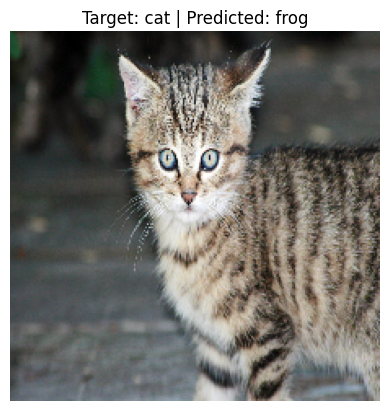

Для cat модель передбачила: frog
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step


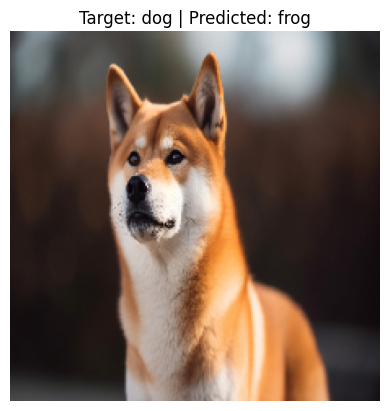

Для dog модель передбачила: frog


In [3]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers
import matplotlib.pyplot as plt
import numpy as np
import os
import time
import urllib.request

# --- Налаштування шляхів для Kaggle ---
ABSOLUTE_PATH = os.getcwd()
LAB_PATH = os.path.join(ABSOLUTE_PATH, "lab06")

# Гарантуємо створення директорії
os.makedirs(LAB_PATH, exist_ok=True)

# Константи
NUM_EPOCHS = 10
TOTAL_IMG_NUM = 2000
VALIDATION_IMG_NUM = 200
TRAINING_IMG_NUM = 500
MODEL_FILENAME = "model.keras"
MODEL_PATH = os.path.join(LAB_PATH, MODEL_FILENAME)
# Посилання на 'raw' для прямого завантаження файлу
MODEL_PATH = os.path.join(LAB_PATH, MODEL_FILENAME)
MODEL_URL = "https://github.com/YuHryshchenko/zpi-zp41_ai_image_processing_HryshchenkoYuliia_KPI_2026/raw/main/lab06/model.keras"

# 1. Завантаження датасету
(train_images, train_labels), (test_images, test_labels) = keras.datasets.cifar10.load_data()

# 2. Ініціалізація назв класів
CLASS_NAMES = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

# 3. Отримання даних для валідації та обмеження кількості навчальних зображень
validation_images, validation_labels = train_images[:TOTAL_IMG_NUM], train_labels[:TOTAL_IMG_NUM]

# Відрізаємо перші VALIDATION_IMG_NUM (валідаційні), а потім беремо лише TRAINING_IMG_NUM зображень для навчання
train_images = train_images[VALIDATION_IMG_NUM:VALIDATION_IMG_NUM + TRAINING_IMG_NUM]
train_labels = train_labels[VALIDATION_IMG_NUM:VALIDATION_IMG_NUM + TRAINING_IMG_NUM]

print(f"[ІНФО] Кількість зображень для навчання: {len(train_images)}")
print(f"[ІНФО] Кількість зображень для валідації: {len(validation_images)}")

# 4. Перетворення на tf.data.Dataset
train_ds = tf.data.Dataset.from_tensor_slices((train_images, train_labels))
test_ds = tf.data.Dataset.from_tensor_slices((test_images, test_labels))
validation_ds = tf.data.Dataset.from_tensor_slices((validation_images, validation_labels))

# 5. Функція попередньої обробки
def process_images(image, label):
    image = tf.image.resize(image, (227, 227))
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

# 6. Створення пайплайну з AUTOTUNE
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.map(process_images, num_parallel_calls=AUTOTUNE).shuffle(buffer_size=1000).batch(32).prefetch(AUTOTUNE)
validation_ds = validation_ds.map(process_images, num_parallel_calls=AUTOTUNE).batch(32).prefetch(AUTOTUNE)
test_ds = test_ds.map(process_images, num_parallel_calls=AUTOTUNE).batch(32).prefetch(AUTOTUNE)

# Функція для створення нової моделі
def build_and_compile_model():
    new_model = models.Sequential([
        layers.Conv2D(96, (11, 11), strides=4, activation='relu', input_shape=(227, 227, 3)),
        layers.MaxPooling2D((3, 3), strides=2),
        layers.Conv2D(256, (5, 5), padding='same', activation='relu'),
        layers.MaxPooling2D((3, 3), strides=2),
        layers.Conv2D(384, (3, 3), padding='same', activation='relu'),
        layers.Conv2D(384, (3, 3), padding='same', activation='relu'),
        layers.Conv2D(256, (3, 3), padding='same', activation='relu'),
        layers.MaxPooling2D((3, 3), strides=2),
        layers.Flatten(),
        layers.Dense(4096, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(4096, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(10, activation='softmax')
    ])
    new_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return new_model

# --- ЛОГІКА ЗАВАНТАЖЕННЯ АБО НАВЧАННЯ МОДЕЛІ ---
model = None
model_loaded_successfully = False

# Спроба завантажити модель з інтернету, якщо локально її немає
if not os.path.exists(MODEL_PATH):
    print(f"\n[ІНФО] Локальної моделі не знайдено. Спроба завантажити з GitHub...")
    try:
        urllib.request.urlretrieve(MODEL_URL, MODEL_PATH)
        print("[УСПІХ] Модель завантажено з GitHub.")
    except Exception as e:
        print(f"[УВАГА] Не вдалося завантажити модель з GitHub: {e}")

# Спроба завантажити ініціалізовану модель у пам'ять
if os.path.exists(MODEL_PATH):
    print("\n[ІНФО] Читання файлу моделі...")
    try:
        model = keras.models.load_model(MODEL_PATH)
        print("[УСПІХ] Модель успішно завантажена з диска!")
        model_loaded_successfully = True
        model.summary()
    except Exception as e:
        print(f"[ПОМИЛКА] Файл знайдено, але неможливо його зчитати. Деталі: {e}")
        model_loaded_successfully = False

# Якщо модель не вдалося завантажити, починаємо тренування з нуля
if not model_loaded_successfully:
    print("\n--- Початок навчання нової моделі ---")
    model = build_and_compile_model()
    model.summary()

    # Налаштування TensorBoard
    root_logdir = os.path.join(LAB_PATH, "logs")
    os.makedirs(root_logdir, exist_ok=True)
    run_logdir = os.path.join(root_logdir, time.strftime("run_%Y_%m_%d-%H_%M_%S"))
    tensorboard_cb = keras.callbacks.TensorBoard(run_logdir)

    # Навчання
    history = model.fit(train_ds, epochs=NUM_EPOCHS, validation_data=validation_ds, callbacks=[tensorboard_cb])

    # Збереження моделі після тренування
    print(f"\n[ІНФО] Збереження навченої моделі у '{MODEL_PATH}'...")
    model.save(MODEL_PATH)

    # ВІДОБРАЖЕННЯ СТАТИСТИКИ (тільки якщо ми щойно навчали)
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs_range = range(1, len(acc) + 1)

    plt.figure(figsize=(14, 5))

    # Графік точності
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy', linewidth=2, marker='o')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', linewidth=2, marker='o')
    plt.legend(loc='lower right', fontsize=12)
    plt.title('Training and Validation Accuracy', fontsize=14)
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Accuracy', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)

    # Графік втрат
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss', linewidth=2, marker='o')
    plt.plot(epochs_range, val_loss, label='Validation Loss', linewidth=2, marker='o')
    plt.legend(loc='upper right', fontsize=12)
    plt.title('Training and Validation Loss', fontsize=14)
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)

    print("\n--- Графіки статистики навчання ---")
    plt.tight_layout()
    plt.show()

# 11. Оцінка (Запускається незалежно від того, чи була модель завантажена чи навчена)
print("\n--- Оцінка на тестових даних ---")
test_loss, test_acc = model.evaluate(test_ds)
print(f"\nТочність на тестових даних: {test_acc:.4f}")

# 12. Демонстрація на нових файлах (Cats & Dogs)
def predict_external_image(url, label_name):
    path = os.path.join(LAB_PATH, f"{label_name}.jpg")
    urllib.request.urlretrieve(url, path)
    
    img = keras.preprocessing.image.load_img(path, target_size=(227, 227))
    img_array = keras.preprocessing.image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0
    
    prediction = model.predict(img_array)
    predicted_class = CLASS_NAMES[np.argmax(prediction)]
    
    plt.imshow(img)
    plt.title(f"Target: {label_name} | Predicted: {predicted_class}")
    plt.axis('off')
    plt.show()
    print(f"Для {label_name} модель передбачила: {predicted_class}")

print("\n--- Перевірка на зовнішніх зображеннях ---")
predict_external_image("https://github.com/YuHryshchenko/zpi-zp41_ai_image_processing_HryshchenkoYuliia_KPI_2026/raw/main/lab06/cat.jpg", "cat")
predict_external_image("https://github.com/YuHryshchenko/zpi-zp41_ai_image_processing_HryshchenkoYuliia_KPI_2026/raw/main/lab06/dog.jpg", "dog")
